In [1]:
# Mounting drive to access the competition data within the drive; Also just downloading other libs
from google.colab import drive
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/accident_files/"
import sys
sys.path.append(base_path)
sys.path.append('/content/drive/MyDrive/accident_files/notebooks')

!pip install pyod
!pip install ultralytics


Mounted at /content/drive


In [13]:
# Download the hdf5 file with spatio-temporal features (acceleration,velocity,vehicle interactions)
import h5py
import numpy as np
with h5py.File("/content/drive/MyDrive/accident_files/lstm_data/features_interactions.h5", "r") as f:
  X = np.array(f["X"])
print(X.shape)

(6009, 16, 50, 19)


In [14]:
# Download the hdf5 file with spatio-temporal features (acceleration, velocity, vehicle interactions)
mean = X.mean(axis=2)
std = X.std(axis=2)
print(mean.shape, std.shape)

# Collapse the features for 50 vehicles into one row; Shape goes from (6009, 16, 50, 39) -> (6009, 16, 39)
max_ = X.max(axis=2)
min_ = X.min(axis=2)
X_reduced = np.concatenate([mean,std,max_],axis = -1)
X_flat = X_reduced.reshape(-1,X_reduced.shape[-1])

(6009, 16, 19) (6009, 16, 19)


In [15]:
# Flatten the 6009 chunks of 16 frames into a single continuous time series
# Shape goes from (6009, 16, 39) -> (96144, 39)
from pyod.models.ts_anomaly_transformer import AnomalyTransformer

X_continuous = X_reduced.reshape(-1, X_reduced.shape[-1])

print(f"Continuous time series shape: {X_continuous.shape}")

# AnomalyTransformer expects (n_timestamps, n_channels)
clf = AnomalyTransformer(device='cuda',window_size=16)
clf.fit(X_continuous)
dump(clf, f'{base_path}models/AnomalyTransformer_interactions.joblib')
print("Model fitting complete!")

Continuous time series shape: (96144, 57)
Model fitting complete!


In [5]:
from pyod.models.ts_anomaly_transformer import AnomalyTransformer
from joblib import dump, load

# save the model
#dump(clf, f'{base_path}models/AnomalyTransformer_clf_new_100_wl.joblib')
# load the model
clf = load(f'{base_path}models/AnomalyTransformer_clf_new.joblib')

Model fitting complete!


In [6]:
import cv2
# Extract frames from a video for YOLO, DeepSORT and RAFT
class VideoFrameExtractor:
    def __init__(self, video_path):
        self.video_path = video_path
        self.cap = cv2.VideoCapture(video_path)

        if not self.cap.isOpened():
            raise ValueError(f"Could not open video: {video_path}")

        # FPS (fallback-safe)
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        if self.fps is None or self.fps <= 0:
            self.fps = 30.0

        # total frames (optional, may be 0 for some codecs)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))

    def get_frames(self):
        """
        Generator yielding:
            frame_idx (int), frame (BGR image as numpy array)
        """
        frame_idx = 0

        while True:
            ret, frame = self.cap.read()
            if not ret:
                break

            yield frame_idx, frame
            frame_idx += 1

        self.cap.release()

    def reset(self):
        """
        Rewinds video for re-use.
        """
        self.cap.release()
        self.cap = cv2.VideoCapture(self.video_path)

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pipeline_interactions import DetectorTracker, OpticalFlow, FeatureBuilder, SequenceBuilder, HDF5Writer, pool_flow

def detect_accident(
    video_path,
    anomaly_model,
    detector_tracker,
    optical_flow,
    device,
    fps=30,
    threshold=0.01,
    alpha=0.6
):
    extractor = VideoFrameExtractor(video_path)
    fps = extractor.fps if extractor.fps > 0 else fps

    feat_builder = FeatureBuilder()
    seq_builder = SequenceBuilder(seq_len=16, max_objects=50, feat_dim=13)


    prev_frame = None

    frame_indices = []
    times = []
    anomaly_scores = []

    for frame_idx, frame in extractor.get_frames():

        # 1. Detection + tracking
        boxes, ids = detector_tracker.update(frame)

        if prev_frame is not None:

            # 2. Optical flow
            flow = optical_flow.compute_flow(prev_frame, frame)

            # 3. Feature extraction
            obj_feats = feat_builder.bbox_to_features(boxes, ids, frame.shape)
            flow_feats = pool_flow(flow, boxes)

            if len(obj_feats) == 0:
                full_feats = np.zeros((1, 13), dtype=np.float32)
            else:
                n = min(len(obj_feats), len(flow_feats))
                full_feats = np.concatenate(
                    [obj_feats[:n], flow_feats[:n]],
                    axis=1
                )

            # 4. Build sequence
            seq = seq_builder.add_frame(full_feats)

            # 5. Anomaly Transformer inference
            if seq is not None:
                # seq is shape (100, 50, 13)
                mean = seq.mean(axis=1)
                std = seq.std(axis=1)
                max_ = seq.max(axis=1)
                # Concatenate to get (100, 39)
                seq_reduced = np.concatenate([mean, std, max_], axis=-1)

                # Get anomaly scores for the 100 frames
                # PyOD decision_function expects 2D array
                scores = anomaly_model.decision_function(seq_reduced)

                # We take the score of the last frame in the sequence
                error = scores[-1]

                frame_indices.append(frame_idx)
                times.append(frame_idx / fps)
                anomaly_scores.append(error)

        prev_frame = frame

    # 6. Detect first anomaly spike
    anomaly_scores = np.array(anomaly_scores)

    # smoothing (important for stability)
    smooth_scores = np.copy(anomaly_scores)
    for i in range(1, len(smooth_scores)):
        smooth_scores[i] = alpha * smooth_scores[i] + (1 - alpha) * smooth_scores[i - 1]

    spike_idx = None
    # for i, s in enumerate(smooth_scores):
    #     if s > threshold:
    #         spike_idx = i
    #         break

    anomaly_scores = np.array(anomaly_scores)

    # smoothing
    smooth_scores = np.copy(anomaly_scores)
    for i in range(1, len(smooth_scores)):
        smooth_scores[i] = alpha * smooth_scores[i] + (1 - alpha) * smooth_scores[i - 1]

    # find peak
    if len(smooth_scores) > 0:
        peak_idx = np.argmax(smooth_scores)
        peak_score = smooth_scores[peak_idx]

        # optional: require it to exceed threshold
        if peak_score > threshold:
            accident_frame = frame_indices[peak_idx]
            accident_time = times[peak_idx]
            score = peak_score

            print("ACCIDENT DETECTED (PEAK)")
            print("Frame:", accident_frame)
            print("Time (s):", accident_time)
            print("Score:", score)
        else:
            accident_frame, accident_time, score = -1, None, None
            print("No anomaly above threshold")

        if spike_idx is not None:
            accident_frame = frame_indices[spike_idx]
            accident_time = times[spike_idx]
            score = smooth_scores[spike_idx]

            print("ACCIDENT DETECTED")
            print("Frame:", accident_frame)
            print("Time (s):", accident_time)
            print("Score:", score)
        else:
            print("No accident detected (Spike)")
    else:
        accident_frame, accident_time, score = -1, None, None
        print("No frames processed.")

    # 7. Visualization
    if len(smooth_scores) > 0:
        plt.plot(times, smooth_scores)
        plt.axhline(threshold, color="g")
        if spike_idx is not None:
            plt.axvline(accident_time, color="r", label="Peak anomaly")
        plt.xlabel("Time (s)")
        plt.ylabel("Anomaly score")
        plt.title("Accident Detection Signal")
        plt.show()

    return accident_frame, accident_time, score


In [12]:
# lstm_autoencoder = tf.keras.models.load_model("/content/drive/MyDrive/accident_files/models/accident_autoencoder.keras")
detector = DetectorTracker("/content/drive/MyDrive/accident_files/models/yolo26n_apr5.pt")
flow = OpticalFlow("/content/drive/MyDrive/accident_files/RAFT/models/raft-sintel.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/content/drive/MyDrive/accident_files/RAFT/core/raft.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/drive/MyDrive/accident_files/RAFT/core/raft.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/drive/MyDrive/accident_files/RAFT/core/raft.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


ACCIDENT DETECTED (PEAK)
Frame: 151
Time (s): 13.455212234706616
Score: 3420513.978645765
No accident detected (Spike)


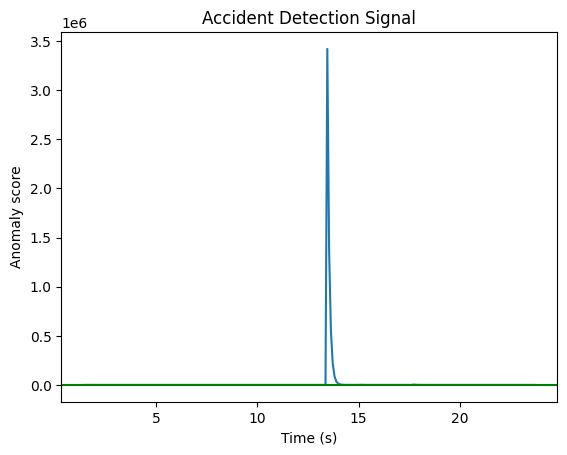

(151, 13.455212234706616, np.float64(3420513.978645765))

In [20]:
# Rolling 16
detect_accident(video_path="/content/drive/MyDrive/accident_files/videos/3dIt2gBnS7o_00.mp4", anomaly_model=clf, detector_tracker=detector, optical_flow=flow, device=device)

ACCIDENT DETECTED (PEAK)
Frame: 150
Time (s): 13.366104868913856
Score: 0.07814663106140776
No accident detected (Spike)


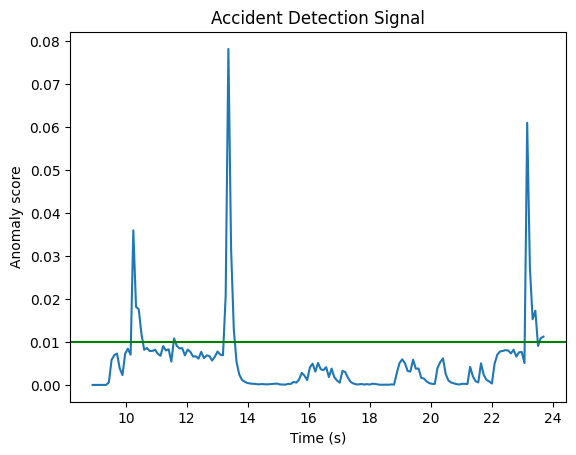

(150, 13.366104868913856, np.float64(0.07814663106140776))

In [ ]:
#Old
detect_accident(video_path="/content/drive/MyDrive/accident_files/videos/3dIt2gBnS7o_00.mp4", anomaly_model=clf, detector_tracker=detector, optical_flow=flow, device=device)

ACCIDENT DETECTED (PEAK)
Frame: 200
Time (s): 13.168498168498168
Score: 75.20842953941046
No accident detected (Spike)


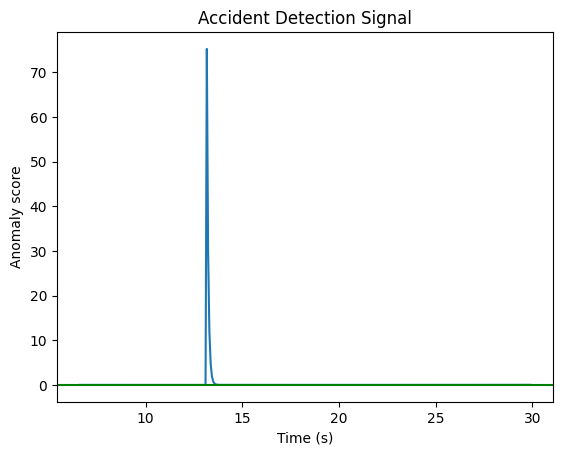

(200, 13.168498168498168, np.float64(75.20842953941046))

In [ ]:
# Feature Interactions but 100
detect_accident(video_path="/content/drive/MyDrive/accident_files/videos/1_FuS-_ctGY_00.mp4", anomaly_model=clf, detector_tracker=detector, optical_flow=flow, device=device)

No anomaly above threshold
No accident detected (Spike)


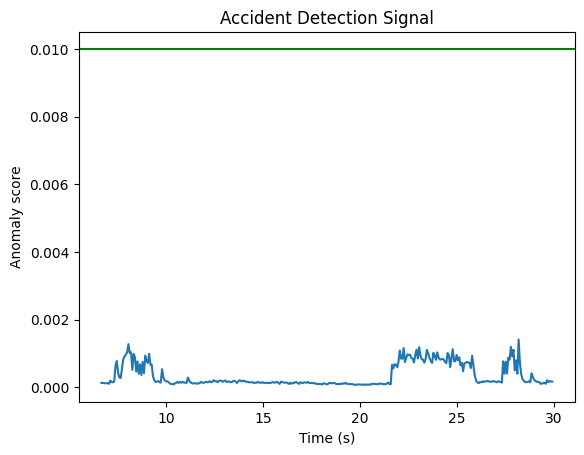

(-1, None, None)

In [ ]:
# Feature Interactions but 100
detect_accident(video_path="/content/drive/MyDrive/accident_files/videos/6s2KTCCo1Hw_00.mp4", anomaly_model=clf, detector_tracker=detector, optical_flow=flow, device=device)

Processing 1/10: WagIvmw1jcI_00.mp4
Processing 2/10: WagIvmw1jcI_01.mp4
Processing 3/10: WbLH4FMzHeo_00.mp4
Processing 4/10: WcZTk9VxOJo_00.mp4
Processing 5/10: WeNSWeu3fe4_00.mp4


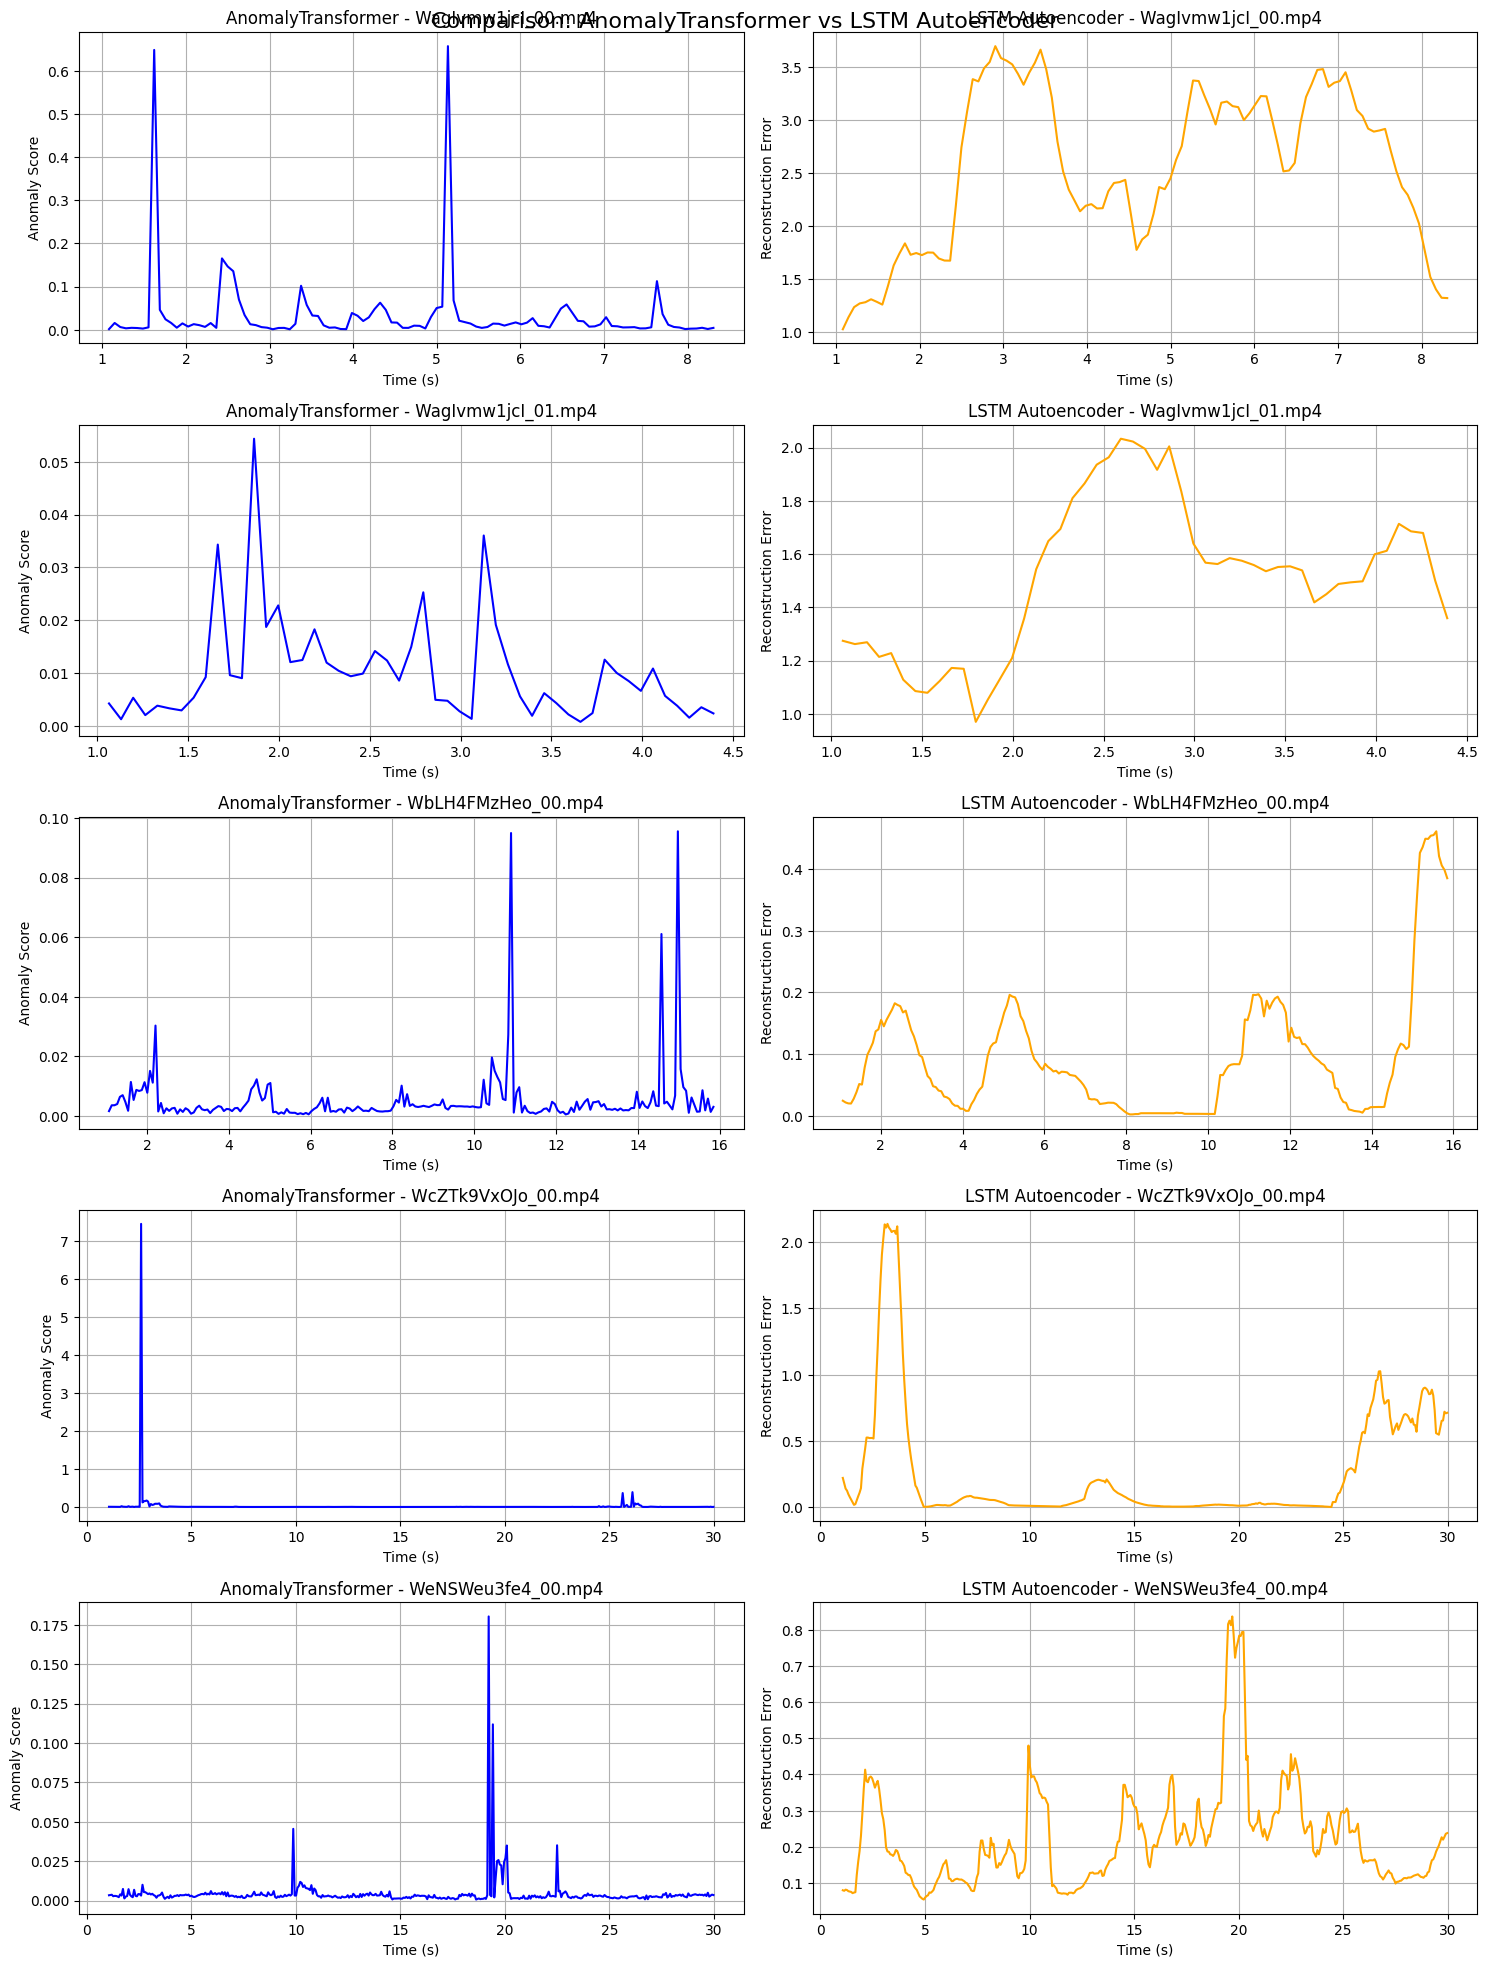

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Load LSTM model
lstm_autoencoder = tf.keras.models.load_model("/content/drive/MyDrive/accident_files/models/accident_autoencoder.keras")

# Get 10 video paths
video_dir = "/content/drive/MyDrive/accident_files/videos/"
all_videos = glob.glob(os.path.join(video_dir, "*.mp4"))
test_videos = all_videos[:5]

def extract_scores(video_path, clf_transformer, lstm_model, detector_tracker, optical_flow, fps=30):
    extractor = VideoFrameExtractor(video_path)
    fps = extractor.fps if extractor.fps > 0 else fps
    feat_builder = FeatureBuilder()

    # Both models now use a sequence length of 16
    seq_builder = SequenceBuilder(seq_len=16, max_objects=50, feat_dim=13)

    times = []
    transformer_scores = []
    lstm_scores = []

    prev_frame = None
    for frame_idx, frame in extractor.get_frames():
        boxes, ids = detector_tracker.update(frame)
        if prev_frame is not None:
            flow = optical_flow.compute_flow(prev_frame, frame)
            obj_feats = feat_builder.bbox_to_features(boxes, ids, frame.shape)
            flow_feats = pool_flow(flow, boxes)

            if len(obj_feats) == 0:
                full_feats = np.zeros((1, 13), dtype=np.float32)
            else:
                n = min(len(obj_feats), len(flow_feats))
                full_feats = np.concatenate([obj_feats[:n], flow_feats[:n]], axis=1)

            seq = seq_builder.add_frame(full_feats)

            t_score, l_score = None, None

            # Inference when sequence is full
            if seq is not None:
                # Transformer Inference
                mean = seq.mean(axis=1)
                std = seq.std(axis=1)
                max_ = seq.max(axis=1)
                seq_reduced = np.concatenate([mean, std, max_], axis=-1)
                scores = clf_transformer.decision_function(seq_reduced)
                t_score = scores[-1]

                # LSTM Inference
                seq_flat = seq.reshape(1, 16, 50*13)
                recon = lstm_model.predict(seq_flat, verbose=0)
                l_score = np.mean((seq_flat - recon)**2)

                times.append(frame_idx / fps)
                transformer_scores.append(t_score)
                lstm_scores.append(l_score)

        prev_frame = frame

    return times, transformer_scores, lstm_scores

# Process and Plot
fig, axes = plt.subplots(len(test_videos), 2, figsize=(15, 4 * len(test_videos)))
fig.suptitle("Comparison: AnomalyTransformer vs LSTM Autoencoder", fontsize=16)

for i, v_path in enumerate(test_videos):
    print(f"Processing {i+1}/10: {os.path.basename(v_path)}")
    times, t_scores, l_scores = extract_scores(v_path, clf, lstm_autoencoder, detector, flow)

    if not times:
        print(f"Skipping {os.path.basename(v_path)} - not enough frames.")
        continue

    # Plot Transformer
    axes[i, 0].plot(times, t_scores, color='blue')
    axes[i, 0].set_title(f"AnomalyTransformer - {os.path.basename(v_path)}")
    axes[i, 0].set_ylabel("Anomaly Score")
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].grid(True)

    # Plot LSTM
    axes[i, 1].plot(times, l_scores, color='orange')
    axes[i, 1].set_title(f"LSTM Autoencoder - {os.path.basename(v_path)}")
    axes[i, 1].set_ylabel("Reconstruction Error")
    axes[i, 1].set_xlabel("Time (s)")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.97)
plt.show()
